In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('/kaggle/input/comment-sentiment/reviews.csv')
df = df.dropna(subset=['text'])

print(df.head())
print(df.info())

                              review_id  \
0   ChZDSUhNMG9nS0VJQ0FnSURaenFqLVpBEAE   
1   ChZDSUhNMG9nS0VJQ0FnTUNnN3FENWRnEAE   
2  ChdDSUhNMG9nS0VJQ0FnSUNoeG9LUy1BRRAB   
3  ChdDSUhNMG9nS0VJQ0FnSUNabEthUGhnRRAB   
4  ChdDSUhNMG9nS0VJQ0FnSUM5dFBXMGdRRRAB   

                                                text  rating  
0  So I ordered a tampiqueña thinking i was going...     1.0  
1  Very bad service, the girl who helped us was n...     1.0  
2  Food was good.  I ordered the flautas.  They w...     4.0  
3  Food was great.  I had beef tacos my wife had ...     4.0  
4  Asked for a chicken fried steak. Got grilled c...     1.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947257 entries, 0 to 947256
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   review_id  947257 non-null  object 
 1   text       947257 non-null  object 
 2   rating     946304 non-null  float64
dtypes: float64(1), object(2)
memory usage: 21.7

In [3]:
def convert_rating_to_label(rating):
    if rating <= 2: return 'Negative'
    elif rating == 3: return 'Neutral'
    else: return 'Positive'

df['sentiment'] = df['rating'].apply(convert_rating_to_label)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) 
    return text

df['clean_text'] = df['text'].apply(clean_text)

print(f"Total samples: {len(df)}")
print("Label Distribution:", df['sentiment'].value_counts().to_dict())

Total samples: 947257
Label Distribution: {'Positive': 767265, 'Negative': 110758, 'Neutral': 69234}


In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(
    df['clean_text'], df['sentiment'], 
    test_size=0.15, random_state=42, stratify=df['sentiment']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.1765, random_state=42, stratify=y_temp
)

In [5]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3), 
    min_df=3, 
    max_df=0.9
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [6]:
class_weights = {
    'Negative': 1.0,
    'Neutral': 2.5,
    'Positive': 0.6
}

maxent_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=500,
    verbose=1,
    class_weight=class_weights,
    C=0.5,
    n_jobs=-1,
    random_state=42
)

maxent_model.fit(X_train_vec, y_train)
print("\n-> Training Finished!")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


convergence after 39 epochs took 60 seconds

-> Training Finished!


Validation Accuracy: 0.8836

>>> FINAL TEST ACCURACY: 0.8841 (88.41%) <<<

              precision    recall  f1-score   support

    Negative       0.83      0.69      0.76     16614
     Neutral       0.37      0.58      0.45     10385
    Positive       0.96      0.94      0.95    115090

    accuracy                           0.88    142089
   macro avg       0.72      0.74      0.72    142089
weighted avg       0.91      0.88      0.89    142089



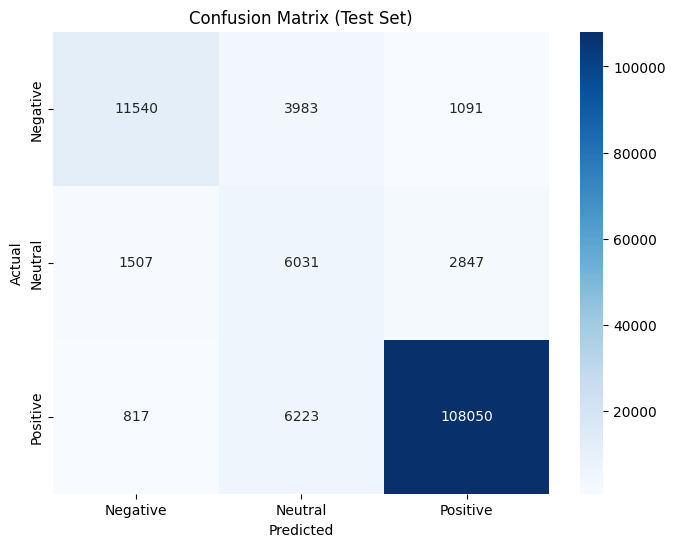

In [7]:
val_acc = accuracy_score(y_val, maxent_model.predict(X_val_vec))
print(f"Validation Accuracy: {val_acc:.4f}")

y_pred = maxent_model.predict(X_test_vec)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n>>> FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%) <<<\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=maxent_model.classes_, 
            yticklabels=maxent_model.classes_)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [8]:
def predict_new_comment(text):
    # Preprocess
    clean = clean_text(text)
    # Vectorize
    vec = vectorizer.transform([clean])
    # Predict
    pred_label = maxent_model.predict(vec)[0]
    pred_proba = np.max(maxent_model.predict_proba(vec))
    
    return pred_label, pred_proba

my_comments = [
    "The food was delicious!",
    
    "It is just normal, nothing special."
]

print("--- DEMO PREDICTION ---")
for comment in my_comments:
    label, confidence = predict_new_comment(comment)
    print(f"Comment: '{comment}'")
    print(f"-> Sentiment: {label} (Confidence: {confidence:.2%})\n")

--- DEMO PREDICTION ---
Comment: 'The food was delicious!'
-> Sentiment: Positive (Confidence: 98.28%)

Comment: 'It is just normal, nothing special.'
-> Sentiment: Neutral (Confidence: 87.65%)

